---
title: OSDF vs S3 streaming benchmark to EC2 (CESM2-LENS, us-west-2)
author: Harsha R. Hampapura
tags:
  - origin:aws
  - platform:aws-ec2
  - dataset:cesm2-le
  - task:benchmark
  - level:intermediate
---
# OSDF vs S3 streaming benchmark to EC2 (CESM2-LENS, us-west-2)

[<span class="tag tag-origin">origin:aws</span>](/tag-index#tag-origin-aws) [<span class="tag tag-platform">platform:aws-ec2</span>](/tag-index#tag-platform-aws-ec2) [<span class="tag tag-dataset">dataset:cesm2-le</span>](/tag-index#tag-dataset-cesm2-le) [<span class="tag tag-task">task:benchmark</span>](/tag-index#tag-task-benchmark) [<span class="tag tag-level">level:intermediate</span>](/tag-index#tag-level-intermediate)

## Overview
Compare **data-access bandwidth to an EC2 instance** for the *same* CESM2-LENS zarr store, read three ways:

- **S3** — native `s3://ncar-cesm2-lens/...` via `s3fs` (anonymous).
- **OSDF (cached)** — `osdf:///aws-opendata/us-west-2/ncar-cesm2-lens/...` via `pelicanfs`, served through the OSDF director + cache nodes.
- **OSDF-direct** — the same OSDF path with `direct_reads=True`, bypassing the cache to stream straight from the origin.

The bucket is in **us-west-2**, so this must run on an EC2 instance in **us-west-2** for a fair, same-region comparison. Comparing OSDF-direct with OSDF-cached isolates the cache's effect; comparing OSDF-direct with S3 isolates the pelican-client + origin overhead.

In [1]:
import os, time
from contextlib import contextmanager
import numpy as np
import pandas as pd
import xarray as xr
import fsspec
from pelicanfs.core import OSDFFileSystem   # importing registers the osdf:// protocol
import matplotlib.pyplot as plt
import seaborn as sns
from dask.distributed import Client, LocalCluster

In [2]:
import logging, warnings
warnings.filterwarnings("ignore", category=ResourceWarning)
for name in ("aiobotocore", "aiohttp", "botocore", "s3fs"):
    logging.getLogger(name).setLevel(logging.CRITICAL)

In [3]:
# m5.4xlarge = 16 vCPU / 64 GB -> 4 workers x 4 threads
cluster = LocalCluster(n_workers=4, threads_per_worker=4)
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 16,Total memory: 62.10 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:46127,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:39235,Total threads: 4
Dashboard: http://127.0.0.1:46129/status,Memory: 15.52 GiB
Nanny: tcp://127.0.0.1:38087,


In [4]:
store    = "atm/daily/cesm2LE-historical-smbb-TREFHTMX.zarr"
variable = "TREFHTMX"
s3_url   = f"s3://ncar-cesm2-lens/{store}"
osdf_url = f"osdf:///aws-opendata/us-west-2/ncar-cesm2-lens/{store}"
print("S3  :", s3_url)
print("OSDF:", osdf_url)

S3  : s3://ncar-cesm2-lens/atm/daily/cesm2LE-historical-smbb-TREFHTMX.zarr
OSDF: osdf:///aws-opendata/us-west-2/ncar-cesm2-lens/atm/daily/cesm2LE-historical-smbb-TREFHTMX.zarr


In [5]:
ds_s3   = xr.open_zarr(fsspec.get_mapper(s3_url, anon=True), consolidated=True, zarr_format=2)[variable]
ds_osdf = xr.open_zarr(fsspec.get_mapper(osdf_url),consolidated=True, zarr_format=2)[variable]
ds_s3

<xarray.DataArray 'TREFHTMX' (member_id: 50, time: 60225, lat: 192, lon: 288)> Size: 666GB
dask.array<open_dataset-TREFHTMX, shape=(50, 60225, 192, 288), dtype=float32, chunksize=(1, 730, 192, 288), chunktype=numpy.ndarray>
Coordinates:
  * member_id  (member_id) <U12 2kB 'r10i1191p1f2' ... 'r9i1171p1f2'
  * time       (time) object 482kB 1850-01-01 12:00:00 ... 2014-12-31 12:00:00
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
Attributes:
    cell_methods:  time: maximum
    long_name:     Maximum reference height temperature over output period
    units:         K

## Build increasing-size subsets
The store is chunked `[member=1, time=730, lat=192, lon=288]` (float32) ≈ **161 MB per chunk**, so the smallest meaningful transfer is one time-chunk. We sweep request size by reading `n` whole chunks (`n = 1, 2, 4, 8, 16` → ≈ 161 MB … 2.6 GB).

To keep every *first* read genuinely uncached:
- each size draws from a **disjoint block of time-chunks** (via `offsets`), so a larger read is never pre-warmed by a smaller one within a pass; and
- each outer try uses a **different `member_id`** (see the run cell), so repeats across passes hit fresh objects.

In [6]:
# OSDF direct reads = bypass the cache node, stream straight from the origin
ds_osdf_direct = xr.open_zarr(fsspec.get_mapper(osdf_url, direct_reads=True),
                              consolidated=True, zarr_format=2)[variable]
# Fallback if your pelicanfs doesn't accept direct_reads via get_mapper:
#   from pelicanfs.core import PelicanMap
#   fs = OSDFFileSystem(direct_reads=True)
#   ds_osdf_direct = xr.open_zarr(PelicanMap(osdf_url.replace("osdf://",""), pelfs=fs),
#                                 consolidated=True, zarr_format=2)[variable]
ds_osdf_direct

<xarray.DataArray 'TREFHTMX' (member_id: 50, time: 60225, lat: 192, lon: 288)> Size: 666GB
dask.array<open_dataset-TREFHTMX, shape=(50, 60225, 192, 288), dtype=float32, chunksize=(1, 730, 192, 288), chunktype=numpy.ndarray>
Coordinates:
  * member_id  (member_id) <U12 2kB 'r10i1191p1f2' ... 'r9i1171p1f2'
  * time       (time) object 482kB 1850-01-01 12:00:00 ... 2014-12-31 12:00:00
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
Attributes:
    cell_methods:  time: maximum
    long_name:     Maximum reference height temperature over output period
    units:         K

In [7]:
chunk_time = 730
n_chunks   = [1, 2, 4, 8, 16]                   # ~0.16, 0.32, 0.65, 1.3, 2.6 GB
offsets    = np.cumsum([0] + n_chunks[:-1])     # disjoint time-block per size: [0,1,3,7,15]

def subset(da, n, member, start_chunk):
    t0 = start_chunk * chunk_time
    return da.isel(member_id=member, time=slice(t0, t0 + n * chunk_time))

In [8]:
class DiagnosticTimer:
    def __init__(self):
        self.diagnostics = []
    @contextmanager
    def time(self, **kwargs):
        tic = time.time()
        yield
        toc = time.time()
        kwargs["runtime"] = toc - tic
        self.diagnostics.append(kwargs)
    def dataframe(self):
        return pd.DataFrame(self.diagnostics)

In [9]:
csv_file_path = "ec2_uswest2_osdf_vs_s3.csv"
N_TRIES = 3            # OUTER loop: independent passes, a new member_id each pass
N_CALLS = 3            # INNER loop: reads per subset (call 1 = first, 2..N = subsequent)
members = [3, 4, 5]    # len(members) == N_TRIES
n_workers = 4

In [11]:
def benchmark_da(da, protocol, member, try_id, diag):
    for n, start in zip(n_chunks, offsets):
        ds = subset(da, n, member, int(start))
        size_mb = ds.nbytes / 1e6
        for call in range(1, N_CALLS + 1):
            cluster.scale(0); cluster.scale(n_workers); client.wait_for_workers(n_workers)
            try:
                with diag.time(dataset_size=size_mb, protocol=protocol, call_number=call,
                               try_id=try_id, member=member):
                    ds.copy().load()
                status = "ok"
            except Exception as e:
                diag.diagnostics.append({"dataset_size": size_mb, "protocol": protocol,
                    "call_number": call, "try_id": try_id, "member": member,
                    "runtime": np.nan, "error": f"{type(e).__name__}: {str(e)[:80]}"})
                status = f"FAIL {type(e).__name__}"
            print(f"try {try_id}  {protocol:11s}  member {member}  {size_mb:8.1f} MB  call {call}/{N_CALLS}  [{status}]")

In [12]:
protocols = [("S3", ds_s3), ("OSDF", ds_osdf), ("OSDF-direct", ds_osdf_direct)]
diag = DiagnosticTimer()
for try_id, member in enumerate(members, start=1):
    for name, da in protocols:
        benchmark_da(da, name, member, try_id, diag)

df = diag.dataframe()
df["MBps"] = df["dataset_size"] / df["runtime"]
df.to_csv(csv_file_path, index=False)
df

try 1  S3           member 0     161.5 MB  call 1/3  [ok]
try 1  S3           member 0     161.5 MB  call 2/3  [ok]


Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x77d14ded4980>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x77d14dcf25d0>, 17140.588240742), (<aiohttp.client_proto.ResponseHandler object at 0x77d14e0cde50>, 17140.681944892)])']
connector: <aiobotocore.httpsession._ProxySSLTCPConnector object at 0x77d14e11ba10>


try 1  S3           member 0     161.5 MB  call 3/3  [ok]


Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x76e881984ad0>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x76e881c825d0>, 17142.959919576), (<aiohttp.client_proto.ResponseHandler object at 0x76e8823a1e50>, 17143.02090031)])']
connector: <aiobotocore.httpsession._ProxySSLTCPConnector object at 0x76e8823e3b60>


try 1  S3           member 0     322.9 MB  call 1/3  [ok]


...

try 3  OSDF         member 2     161.5 MB  call 2/3  [ok]
try 3  OSDF         member 2     161.5 MB  call 3/3  [ok]
try 3  OSDF         member 2     322.9 MB  call 1/3  [ok]
try 3  OSDF         member 2     322.9 MB  call 2/3  [ok]
try 3  OSDF         member 2     322.9 MB  call 3/3  [ok]
try 3  OSDF         member 2     645.9 MB  call 1/3  [ok]
try 3  OSDF         member 2     645.9 MB  call 2/3  [ok]
try 3  OSDF         member 2     645.9 MB  call 3/3  [ok]
try 3  OSDF         member 2    1291.7 MB  call 1/3  [ok]
try 3  OSDF         member 2    1291.7 MB  call 2/3  [ok]
try 3  OSDF         member 2    1291.7 MB  call 3/3  [ok]
try 3  OSDF         member 2    2583.4 MB  call 1/3  [ok]
try 3  OSDF         member 2    2583.4 MB  call 2/3  [ok]
try 3  OSDF         member 2    2583.4 MB  call 3/3  [ok]
try 3  OSDF-direct  member 2     161.5 MB  call 1/3  [ok]
try 3  OSDF-direct  member 2     161.5 MB  call 2/3  [ok]
try 3  OSDF-direct  member 2     161.5 MB  call 3/3  [ok]
try 3  OSDF-di

2026-09-21 20:09:18,512 - distributed.worker - ERROR - Compute Failed
Key:       ('open_dataset-TREFHTMX-getitem-c00ee5bc9771e7cad50726a39d9467e4', 6, 0, 0)
State:     executing
Task:  <Task ('open_dataset-TREFHTMX-getitem-c00ee5bc9771e7cad50726a39d9467e4', 6, 0, 0) _execute_subgraph(...)>
Exception: "RuntimeError('error during blosc decompression: -1')"
Traceback: '  File "/home/ubuntu/osdf-env/lib/python3.14/site-packages/dask/array/core.py", line 140, in getter\n    c = np.asarray(c)\n  File "/home/ubuntu/osdf-env/lib/python3.14/site-packages/xarray/core/indexing.py", line 691, in __array__\n    return np.asarray(to_numpy(self.get_duck_array()), dtype=dtype, copy=copy)\n                               ~~~~~~~~~~~~~~~~~~~^^\n  File "/home/ubuntu/osdf-env/lib/python3.14/site-packages/xarray/core/indexing.py", line 697, in get_duck_array\n    return self.array.get_duck_array()\n           ~~~~~~~~~~~~~~~~~~~~~~~~~^^\n  File "/home/ubuntu/osdf-env/lib/python3.14/site-packages/xarray/core

try 3  OSDF-direct  member 2    2583.4 MB  call 1/3  [FAIL RuntimeError]
try 3  OSDF-direct  member 2    2583.4 MB  call 2/3  [ok]
try 3  OSDF-direct  member 2    2583.4 MB  call 3/3  [FAIL RuntimeError]


2026-09-21 20:09:41,448 - distributed.worker - ERROR - Compute Failed
Key:       ('open_dataset-TREFHTMX-getitem-c00ee5bc9771e7cad50726a39d9467e4', 6, 0, 0)
State:     executing
Task:  <Task ('open_dataset-TREFHTMX-getitem-c00ee5bc9771e7cad50726a39d9467e4', 6, 0, 0) _execute_subgraph(...)>
Exception: "RuntimeError('error during blosc decompression: -1')"
Traceback: '  File "/home/ubuntu/osdf-env/lib/python3.14/site-packages/dask/array/core.py", line 140, in getter\n    c = np.asarray(c)\n  File "/home/ubuntu/osdf-env/lib/python3.14/site-packages/xarray/core/indexing.py", line 691, in __array__\n    return np.asarray(to_numpy(self.get_duck_array()), dtype=dtype, copy=copy)\n                               ~~~~~~~~~~~~~~~~~~~^^\n  File "/home/ubuntu/osdf-env/lib/python3.14/site-packages/xarray/core/indexing.py", line 697, in get_duck_array\n    return self.array.get_duck_array()\n           ~~~~~~~~~~~~~~~~~~~~~~~~~^^\n  File "/home/ubuntu/osdf-env/lib/python3.14/site-packages/xarray/core

,dataset_size,protocol,call_number,try_id,member,runtime,error,MBps
0,161.46432,S3,1,1,0,2.761752,NaN,58.464445
1,161.46432,S3,2,1,0,1.355630,NaN,119.106489
2,161.46432,S3,3,1,0,2.326924,NaN,69.389602
3,322.92864,S3,1,1,0,3.326504,NaN,97.077498
4,322.92864,S3,2,1,0,3.208972,NaN,100.633058
...,...,...,...,...,...,...,...,...
130,1291.71456,OSDF-direct,2,3,2,8.755144,NaN,147.537780
131,1291.71456,OSDF-direct,3,3,2,9.446928,NaN,136.733827
132,2583.42912,OSDF-direct,1,3,2,NaN,RuntimeError: error during blosc decompression...,NaN
133,2583.42912,OSDF-direct,2,3,2,16.942302,NaN,152.483952


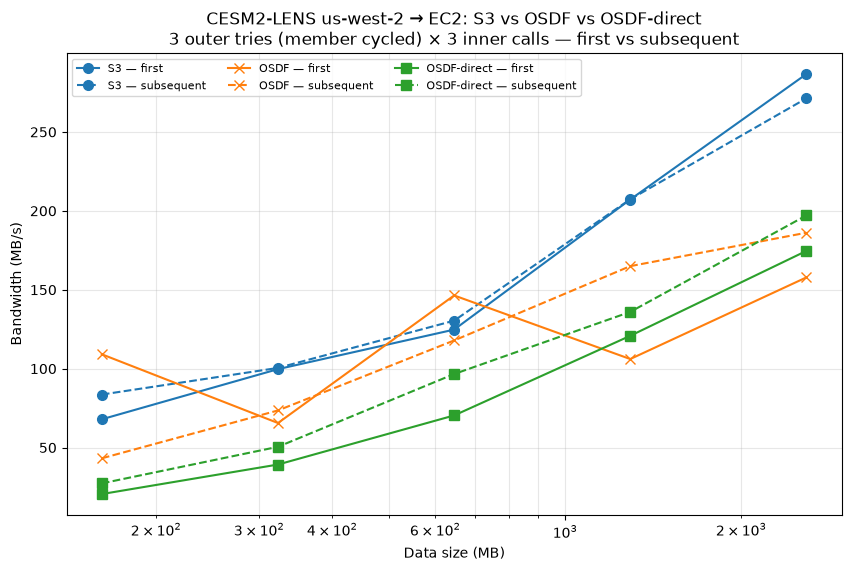

In [14]:
colors = {"S3": "#1f77b4", "OSDF": "#ff7f0e", "OSDF-direct": "#2ca02c"}
marker = {"S3": "o", "OSDF": "x", "OSDF-direct": "s"}
fig, ax = plt.subplots(figsize=(10, 6))
for proto in ["S3", "OSDF", "OSDF-direct"]:
    sub = df[df.protocol == proto]
    first  = sub[sub.call_number == 1].groupby("dataset_size").MBps.mean()
    subseq = sub[sub.call_number  > 1].groupby("dataset_size").MBps.mean()
    ax.plot(first.index,  first.values,  color=colors[proto], marker=marker[proto], ms=7, label=f"{proto} — first")
    ax.plot(subseq.index, subseq.values, color=colors[proto], marker=marker[proto], ms=7, ls="--", label=f"{proto} — subsequent")
ax.set_xlabel("Data size (MB)"); ax.set_ylabel("Bandwidth (MB/s)"); ax.set_xscale("log")
ax.set_title(f"CESM2-LENS us-west-2 → EC2: S3 vs OSDF vs OSDF-direct\n"
             f"{N_TRIES} outer tries (member cycled) × {N_CALLS} inner calls — first vs subsequent")
ax.grid(True, which="both", alpha=0.3); ax.legend(ncol=3, fontsize=8)
plt.show()

### Summary — bandwidth vs data size

**Method:** `N_TRIES = 3` outer passes (a different `member_id` each pass, so first reads are genuinely uncached) × `N_CALLS = 3` inner reads per subset (call 1 = *first*, calls 2–3 = *subsequent*), each size from a disjoint block of chunks. Median bandwidth (MB/s):

| Size | S3 first / subs | OSDF first / subs | OSDF-direct first / subs |
|------|-----------------|-------------------|--------------------------|
| 161 MB  | 59 / 68 | 110 / 55 | 20 / 28 |
| 323 MB  | 98 / 100 | 67 / 53 | 39 / 49 |
| 646 MB  | 126 / 124 | 153 / 133 | 69 / 93 |
| 1292 MB | 207 / 208 | 92 / 161 | 116 / 139 |
| 2583 MB | 287 / 275 | 135 / 190 | 175 / 211 |

- **S3** scales smoothly and monotonically (≈ 59 → 287 MB/s) and is essentially flat first-vs-subsequent (no client cache), making it the fastest, most predictable path at ≳ 646 MB.
- **OSDF-direct** also scales cleanly (≈ 20 → 175 MB/s) and is the most *consistent* OSDF path, but is slowest at small/mid sizes (pelican-client + origin overhead). Its modest first→subsequent lift is connection warm-up, not data caching.
- **OSDF-cached** is **erratic and non-monotonic** — sometimes the fastest at a size (110 MB/s at 161 MB), sometimes among the slowest, with the first-vs-subsequent ordering flipping size to size. That is the signature of the OSDF director routing successive requests to *different* cache nodes rather than a clean warm-up.
- None of the three nears the m5.4xlarge NIC ceiling (~10 Gbps ≈ 1250 MB/s; peak here ≈ 290 MB/s ≈ 2.3 Gbps): decode/parallelism, not the network, is the bottleneck. These are **relative protocol comparisons, not peak throughput.**

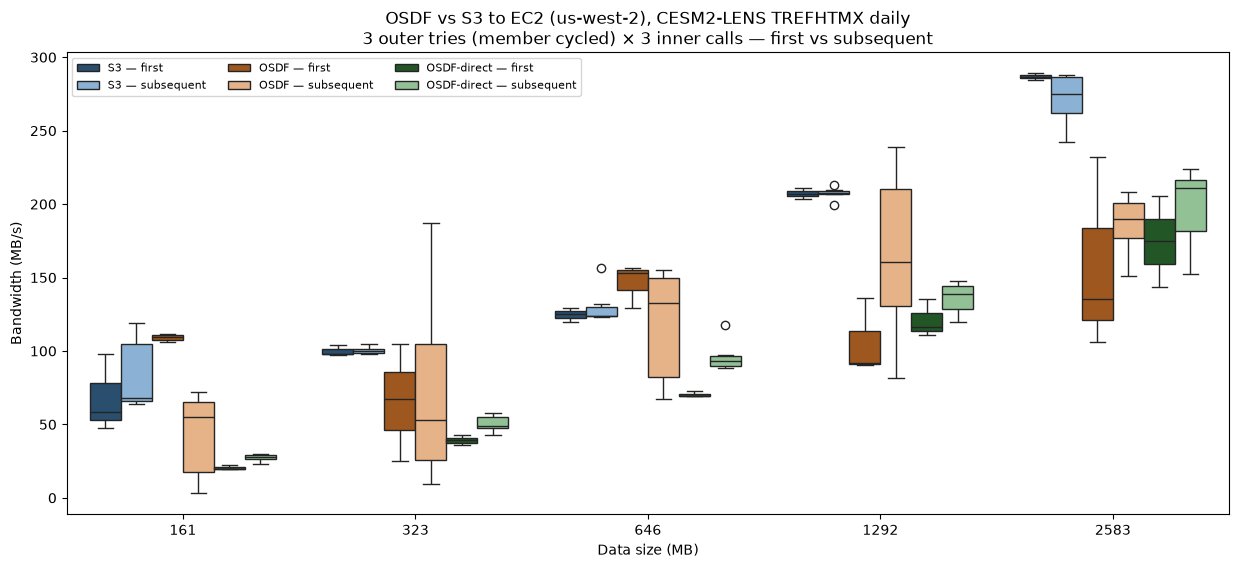

In [15]:
dfb = df.copy()
dfb["dataset_size"] = dfb["dataset_size"].astype(float).round(0).astype(int)
dfb["access"] = np.where(dfb["call_number"] == 1, "first", "subsequent")
dfb["series"] = dfb["protocol"] + " — " + dfb["access"]
order = sorted(dfb["dataset_size"].unique())
hue_order = ["S3 — first","S3 — subsequent","OSDF — first","OSDF — subsequent",
             "OSDF-direct — first","OSDF-direct — subsequent"]
palette = {"S3 — first":"#1f4e79","S3 — subsequent":"#7fb3e0",
           "OSDF — first":"#b3560a","OSDF — subsequent":"#f5b27a",
           "OSDF-direct — first":"#1b5e20","OSDF-direct — subsequent":"#8bc98f"}
plt.figure(figsize=(15, 6))
sns.boxplot(data=dfb, x="dataset_size", y="MBps", hue="series", order=order, hue_order=hue_order, palette=palette)
plt.xlabel("Data size (MB)"); plt.ylabel("Bandwidth (MB/s)")
plt.title(f"OSDF vs S3 to EC2 (us-west-2), CESM2-LENS TREFHTMX daily\n"
          f"{N_TRIES} outer tries (member cycled) × {N_CALLS} inner calls — first vs subsequent")
plt.legend(title="", ncol=3, fontsize=8); plt.show()

### Summary — distributions (first vs subsequent)

Each box spans up to `N_TRIES × N_CALLS` reads (3 first + 6 subsequent per size per series).

- **Spread is the story.** S3 is tight and reproducible (e.g. 284–289 MB/s across all first-access reads at 2583 MB). OSDF-cached is by far the widest — its *subsequent* reads span 10–187 MB/s at 323 MB and 81–239 MB/s at 1292 MB. That run-to-run swing, together with the non-monotonic medians above, is consistent with the **director spreading requests across different cache nodes** (varying proximity/state) rather than a repeatable cold→warm transition.
- **OSDF-direct is the tight OSDF path** (e.g. 19.5–30 MB/s across all reads at 161 MB), confirming that most of OSDF-cached's variance lives in the cache/routing layer, not the client or origin.
- **Reliability:** 2 of 135 reads failed — both **OSDF-direct at 2583 MB** (`RuntimeError: error during blosc decompression: -1`), i.e. a truncated/corrupt chunk on the origin path for the largest reads.
- **Takeaway:** for same-region, AWS-native data read from EC2, native **S3 is fastest and most consistent**. OSDF's value here is not raw in-region throughput — it is federation, a uniform client across heterogeneous origins, and cache locality for the repeated/shared access patterns this single-client, single-region test does not reward.